In [2]:
from real_time_weather_ingestion import main_scrapper
from radar_image_processor import image_to_possible_storm
from storm_object_detector import storm_object_checker,storm_pixel_coordinates
from datetime import datetime 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from PIL import Image
from matplotlib import colors

In [3]:
all_station_data = pd.read_csv('overall_station.csv')
all_station_data.head

<bound method NDFrame.head of                    Station Name  Latitude  Longitude Station ID
0           Ang Mo Kio Avenue 5   1.37640  103.84920       S109
1                Nanyang Avenue   1.34583  103.68166        S44
2                    Pulau Ubin   1.41680  103.96730       S106
3                   Banyan Road   1.25600  103.67900       S117
4                Kim Chuan Road   1.33990  103.88780        S43
5            East Coast Parkway   1.31350  103.96250       S107
6       Upper Changi Road North   1.36780  103.98260        S24
7           Tuas South Avenue 3   1.29377  103.61843       S115
8              Semakau Landfill   1.18900  103.76800       S102
9                   Scotts Road   1.31055  103.83650       S111
10                      Sentosa   1.25000  103.82790        S60
11            Yio Chu Kang Road   1.37999  103.87643       S219
12         Ang Mo Kio Avenue 10   1.36019  103.85335       S216
13             Bishan Street 13   1.35041  103.85526       S217
14        

In [4]:
# shayne help me make sure ur weather station dataframe is named as all_station_data , then juz run this whole cell , at the end just upload all_station_data to the db will do 

########################################################################################
# do not change
lat_min, lat_max = 1.15, 1.47
lon_min, lon_max = 103.56, 104.14   
########################################################################################

########################################################################################
# do not change
scale_x = 217 / 853
scale_y = 120 / 479
########################################################################################


def latlon_to_xy(lat, lon, lat_min, lat_max, lon_min, lon_max, width, height):
    """
    Convert latitude and longitude to pixel coordinates on the radar image grid.

    Args:
        lat, lon : float
        lat_min, lat_max, lon_min, lon_max : float
            Bounding box of the radar coverage.
        width, height : int
            Dimensions of the radar image (e.g. 217x120).

    Returns:
        (x, y) pixel coordinates (integers)
    """

    # normalize longitude to horizontal position
    x = (lon - lon_min) / (lon_max - lon_min) * (width - 1)
    # normalize latitude to vertical position (note inversion: north is top)
    y = (lat_max - lat) / (lat_max - lat_min) * (height - 1)

    return int(round(x)), int(round(y))

def basemap_to_radar(X, Y):
    x = X * scale_x
    y = Y * scale_y
    return int(round(x)), int(round(y))

all_station_data['coord_basemap'] = all_station_data.apply(lambda row : latlon_to_xy(row['Latitude'],row['Longitude'],lat_min, lat_max, lon_min, lon_max,853,479),axis = 1)

all_station_data.rename(columns={'Station Name':'station_name','Latitude':'latitude','Longitude':'longitude','Station ID':'station_id'},inplace = True)


all_station_data["coord"] = all_station_data["coord_basemap"].apply(lambda xy: basemap_to_radar(xy[0], xy[1]))

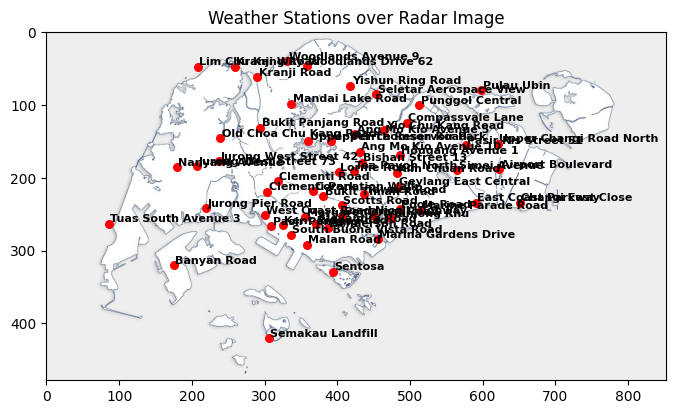

In [5]:
xs, ys = zip(*all_station_data["coord_basemap"])

# Open radar image
img = Image.open("sample_data/base-853.png")

plt.figure(figsize=(8, 5))
plt.imshow(img)

# Plot weather stations
plt.scatter(xs, ys, color="red", s=30)

# Add station labels
for i, row in all_station_data.iterrows():
    x, y = row["coord_basemap"]      # unpack tuple
    plt.text(x + 2, y - 2, row["station_name"],
             color="black", fontsize=8, weight="bold")

plt.title("Weather Stations over Radar Image")
plt.show()

# H, W = img_or_grid.shape[:2]

# plt.figure(figsize=(8,5))
# # If it's a reflectivity grid/array:
# plt.imshow(img_or_grid, origin="upper")  # origin='upper' puts y=0 at top (radar-style)
# # If it's a Pillow/NumPy RGBA image, same call works.

# plt.scatter(stations_df["x"], stations_df["y"], s=35, c="red", label="Stations")

# # label each station
# for _, r in stations_df.iterrows():
#     plt.text(r["x"]+2, r["y"]-2, str(r["station_id"]),
#              fontsize=8, color="red", va="bottom", ha="left")

# # Do NOT also invert y if you used origin='upper'. Pick ONE of these:
# # plt.gca().invert_yaxis()        # <- use this only if you did NOT set origin='upper'

# plt.xlim(-2, W+2)
# plt.ylim(H+2, -2)  # equivalent to origin='upper' if you prefer this style
# plt.title("Weather Stations over Radar Image")
# plt.xlabel("X (pixel)"); plt.ylabel("Y (pixel)")
# plt.legend()
# plt.tight_layout()
# plt.show()

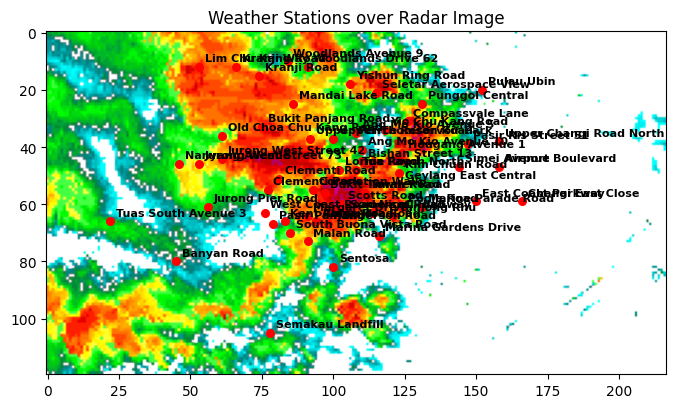

In [8]:
xs, ys = zip(*all_station_data["coord"])

# Open radar image
img = Image.open("sample_data/test_image.png")

plt.figure(figsize=(8, 5))
plt.imshow(img)

# Plot weather stations
plt.scatter(xs, ys, color="red", s=30)

# Add station labels
for i, row in all_station_data.iterrows():
    x, y = row["coord"]      # unpack tuple
    plt.text(x + 2, y - 2, row["station_name"],
             color="black", fontsize=8, weight="bold")

plt.title("Weather Stations over Radar Image")
plt.show()

In [7]:
# pull dummy data to work with
# ts_str = '202510091010'
current_datetime = datetime(2025,10,9,10,10,0)
run_datetime= current_datetime.replace(minute = 10,second = 0, microsecond=0).isoformat()

dummy_data = main_scrapper(run_datetime)
dummy_data

# humidity_df = humidity_api(run_datetime)
# temperature_df = temperature_api(run_datetime)
# wind_speed_df = wind_speed_api(run_datetime)
# wind_direction_df = wind_direction_api(run_datetime)
# rainfall_df = rainfall_api(run_datetime)


,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6


In [9]:
dummy_data = dummy_data.merge(all_station_data, on = 'station_id' , how = 'left')
dummy_data

,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,station_name,latitude,longitude,coord_basemap,coord
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2,Ang Mo Kio Avenue 5,1.37640,103.84920,"(425, 140)","(108, 35)"
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8,Pulau Ubin,1.41680,103.96730,"(598, 79)","(152, 20)"
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8,Banyan Road,1.25600,103.67900,"(175, 320)","(45, 80)"
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5,East Coast Parkway,1.31350,103.96250,"(591, 234)","(150, 59)"
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4,Tuas South Avenue 3,1.29377,103.61843,"(86, 263)","(22, 66)"
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2,Sentosa,1.25000,103.82790,"(394, 329)","(100, 82)"
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1,Nanyang Avenue,1.34583,103.68166,"(179, 185)","(46, 46)"
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6,Kim Chuan Road,1.33990,103.88780,"(482, 194)","(123, 49)"
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,Scotts Road,1.31055,103.83650,"(406, 238)","(103, 60)"


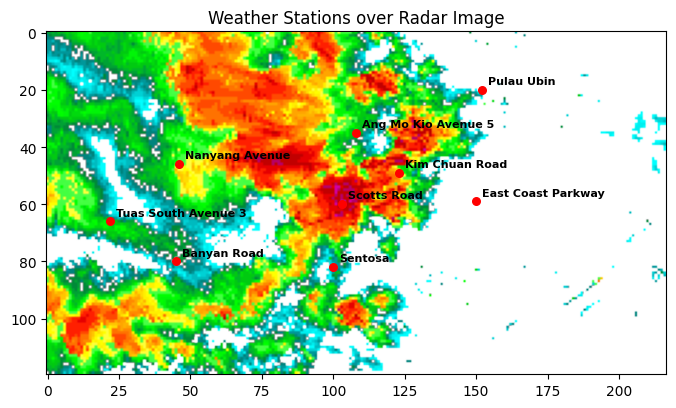

In [11]:
xs, ys = zip(*dummy_data["coord"])

# Open radar image
img = Image.open("sample_data/test_image.png")

plt.figure(figsize=(8, 5))
plt.imshow(img)

# Plot weather stations
plt.scatter(xs, ys, color="red", s=30)

# Add station labels
for i, row in dummy_data.iterrows():
    x, y = row["coord"]      # unpack tuple
    plt.text(x + 2, y - 2, row["station_name"],
             color="black", fontsize=8, weight="bold")

plt.title("Weather Stations over Radar Image")
plt.show()

In [14]:
with open('sample_data/test_image.png','rb') as f:
    data = f.read()

In [ ]:
# print(type(data))
# print(data)

In [15]:
possible_storm_grid, possible_storm_df = image_to_possible_storm(data,50,0)

In [16]:
possible_storm_df

,grid_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x
0,1,0.440,61.0,0.0,42.0,0.20,41.60
1,2,0.528,61.0,1.0,46.0,1.00,45.50
2,3,200.288,69.0,37.0,85.0,37.40,84.92
3,4,11.088,65.0,6.0,96.0,5.52,95.52
4,5,0.088,58.0,1.0,115.0,1.00,115.00
5,6,0.176,58.0,2.0,48.0,2.50,48.00
6,7,0.088,50.0,6.0,85.0,6.00,85.00
7,8,0.088,50.0,8.0,48.0,8.00,48.00
8,9,8.888,65.0,18.0,114.0,18.27,114.48
9,10,0.088,50.0,17.0,86.0,17.00,86.00


In [ ]:
H, W = possible_storm_grid.shape

# 1) Collect actual storm IDs (exclude background 0)
labels = np.array(sorted(np.unique(possible_storm_grid)))
labels = labels[labels != 0]
N = len(labels)
if N == 0:
    labels = np.array([0]); N = 1

# 2) Map real labels -> 0..N-1 for coloring
lab2idx = {lab: i for i, lab in enumerate(labels)}
idx_grid = np.vectorize(lambda v: lab2idx.get(v, -1))(possible_storm_grid)  # -1 for background

# 3) Build discrete colormap (one color per storm), mask background
cmap = plt.get_cmap("tab20", N)
norm = colors.BoundaryNorm(np.arange(N+1)-0.5, N)  # bins centered at 0..N-1
plot_data = np.ma.masked_where(idx_grid < 0, idx_grid)  # hide background

# 4) Plot
plt.figure(figsize=(10,5))
im = plt.imshow(plot_data, cmap=cmap, norm=norm, origin='upper')

# Colorbar with REAL storm IDs
cbar = plt.colorbar(im, ticks=np.arange(N))
cbar.ax.set_yticklabels([str(l) for l in labels])
cbar.set_label("Storm ID", rotation=270, labelpad=15)

# 5) Stations
xs = [xy[0] for xy in dummy_data["coord"]]
ys = [xy[1] for xy in dummy_data["coord"]]
plt.scatter(xs, ys, s=30, c='red', edgecolors='white', linewidths=0.7, label='Stations')

for sid, (x, y) in zip(dummy_data['station_id'], dummy_data['coord']):
    plt.annotate(str(sid), (x, y), xytext=(4, -4), textcoords='offset points',
                 fontsize=8, color='white', bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.4))

plt.xlim(0, W-1); plt.ylim(H-1, 0)
plt.title("Storm grid with weather stations")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
possible_storm_df

In [22]:
def storm_pixel_coordinates(
        storm_id
        ,full_storm_grid
): 
        # binary mask 
        storm_mask = (full_storm_grid == storm_id).astype(np.uint8)

        #print(int(storm_mask.sum()))

        # return coordinates for every pixel 
        ys,xs = np.where(storm_mask)

        # pack into dataframe 
        coord = list(zip(xs,ys))
        df = pd.DataFrame({'coord':coord})

        return df

def metric_threshold_calc(
        input_df
        ,wind_speed_threshold
        ,rainfall_threshold
        ,temperature_threshold
        ,humidty_threshold
): 
        res = False
        threshold_flags = [False,False,False,False]

        # if single station 
        if input_df.shape[0] == 1: 
                if input_df['wind_speed_knots'].iloc[0] >= wind_speed_threshold:
                        threshold_flags[0] = True
                if input_df['rainfall_mm'].iloc[0] >= rainfall_threshold:
                        threshold_flags[1] = True
                if input_df['temperature_c'].iloc[0] <= temperature_threshold:
                        threshold_flags[2] = True
                if input_df['humidity_pct'].iloc[0] >= humidty_threshold:
                        threshold_flags[3] = True


        # if multi station, average all 
        else:
                cols_to_avg = ["wind_speed_knots", "rainfall_mm", "temperature_c", "humidity_pct"]
                mean_df = input_df[cols_to_avg].mean()

                if mean_df['wind_speed_knots'] >= wind_speed_threshold:
                        threshold_flags[0] = True
                if mean_df['rainfall_mm'] >= rainfall_threshold:
                        threshold_flags[1] = True
                if mean_df['temperature_c'] <= temperature_threshold:
                        threshold_flags[2] = True
                if mean_df['humidity_pct'] >= humidty_threshold:
                        threshold_flags[3] = True

        if sum(threshold_flags) == 4:
                res = True
        return res


def x_y_distance(
        tuple
        ,x2
        ,y2
) : 
        if isinstance(tuple, float) and np.isnan(tuple):
                d = np.inf
        else:
                x1 = tuple[0]
                y1 = tuple[1]
                d = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        return d

def storm_object_checker(
        storm_id
        ,possible_storm_grid

        ,weather_data_df

        # threshholds 
        ,wind_speed_threshold
        ,rainfall_threshold
        ,temperature_threshold
        ,humidty_threshold

        ,dist_tol
): 
        curr_storm = storm_pixel_coordinates(storm_id, possible_storm_grid)

        nearby_stations = pd.merge(weather_data_df,curr_storm,how='inner' , on = 'coord')
        
        # storm does not encompass any stations
        if nearby_stations.shape[0] == 0:
                # find centriod point first
                xs, ys = zip(*curr_storm["coord"])

                anchor_y = round(float(np.mean(ys)),0)
                anchor_x = round(float(np.mean(xs)),0)
                weather_data_df['distance_to_station'] = weather_data_df['coord'].apply(lambda x: x_y_distance(x,anchor_x,anchor_y))
                weather_data_df.sort_values(by='distance_to_station',ascending=True,inplace=True,na_position='last')
                if weather_data_df['distance_to_station'].iloc[0] <= dist_tol:
                        res = True
                        return res 
                # call and return nearest station 
                nearby_stations = weather_data_df.head(1)

        res = metric_threshold_calc(nearby_stations,wind_speed_threshold,rainfall_threshold,temperature_threshold,humidty_threshold)
        
        return res


In [20]:
# take in grid and df, for each storm pull grid for that storm 
# then pull xy coord for every pixel in that storm 
# then check if it contains any of the station data 

test_storm= storm_pixel_coordinates(3,possible_storm_grid)
test_storm

# xs, ys = zip(*test_storm["coord"])

# anchor_y = round(float(np.mean(ys)),0)
# anchor_x = round(float(np.mean(xs)),0)

# print(anchor_x,anchor_y)
contain_station = pd.merge(dummy_data,test_storm ,how = 'inner', on = 'coord')
contain_station

# metrics above threshold 
# pull first 




,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,station_name,latitude,longitude,coord_basemap,coord
0,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,Scotts Road,1.31055,103.8365,"(406, 238)","(103, 60)"


In [ ]:
dummy_data

In [23]:
above = metric_threshold_calc(contain_station,5,1,25,90)
above


True

In [ ]:
test= possible_storm_df['new_id'].unique().tolist()
test

In [24]:
test = possible_storm_df


In [25]:
test['output'] = test['grid_id'].apply(lambda x: storm_object_checker(x,possible_storm_grid,dummy_data,5,2,25,90,40))
test

,grid_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x,output
0,1,0.440,61.0,0.0,42.0,0.20,41.60,False
1,2,0.528,61.0,1.0,46.0,1.00,45.50,False
2,3,200.288,69.0,37.0,85.0,37.40,84.92,True
3,4,11.088,65.0,6.0,96.0,5.52,95.52,True
4,5,0.088,58.0,1.0,115.0,1.00,115.00,True
5,6,0.176,58.0,2.0,48.0,2.50,48.00,False
6,7,0.088,50.0,6.0,85.0,6.00,85.00,True
7,8,0.088,50.0,8.0,48.0,8.00,48.00,True
8,9,8.888,65.0,18.0,114.0,18.27,114.48,True
9,10,0.088,50.0,17.0,86.0,17.00,86.00,True


In [26]:
filtered = test[test['output']]
filtered

,grid_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x,output
2,3,200.288,69.0,37.0,85.0,37.40,84.92,True
3,4,11.088,65.0,6.0,96.0,5.52,95.52,True
4,5,0.088,58.0,1.0,115.0,1.00,115.00,True
6,7,0.088,50.0,6.0,85.0,6.00,85.00,True
7,8,0.088,50.0,8.0,48.0,8.00,48.00,True
8,9,8.888,65.0,18.0,114.0,18.27,114.48,True
9,10,0.088,50.0,17.0,86.0,17.00,86.00,True
10,11,0.088,50.0,19.0,90.0,19.00,90.00,True
11,12,0.088,50.0,25.0,96.0,25.00,96.00,True
12,13,0.352,50.0,29.0,96.0,29.00,95.50,True


In [27]:
print(type(possible_storm_grid))

<class 'numpy.ndarray'>


In [28]:
import io
import pg8000

buf = io.BytesIO()
np.save(buf, possible_storm_grid)
buf.seek(0)
binary_data = pg8000.Binary(buf.read())
print(type(binary_data))

<class 'bytes'>


In [29]:
filtered.dtypes

grid_id         int64
area_px       float64
peak_dbz      float64
anchor_y      float64
anchor_x      float64
centroid_y    float64
centroid_x    float64
output           bool
dtype: object

In [30]:
filtered['timestamp'] = 'test'

filtered

/var/folders/c9/rl6pcdvd1_xb6ng3n8l9wr2w0000gn/T/ipykernel_45894/886104433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['timestamp'] = 'test'


,grid_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x,output,timestamp
2,3,200.288,69.0,37.0,85.0,37.40,84.92,True,test
3,4,11.088,65.0,6.0,96.0,5.52,95.52,True,test
4,5,0.088,58.0,1.0,115.0,1.00,115.00,True,test
6,7,0.088,50.0,6.0,85.0,6.00,85.00,True,test
7,8,0.088,50.0,8.0,48.0,8.00,48.00,True,test
8,9,8.888,65.0,18.0,114.0,18.27,114.48,True,test
9,10,0.088,50.0,17.0,86.0,17.00,86.00,True,test
10,11,0.088,50.0,19.0,90.0,19.00,90.00,True,test
11,12,0.088,50.0,25.0,96.0,25.00,96.00,True,test
12,13,0.352,50.0,29.0,96.0,29.00,95.50,True,test


In [31]:
new_order = ['timestamp','grid_id','centroid_x','centroid_y','anchor_x','anchor_y','peak_dbz','area_px','output']

filtered = filtered[new_order]
filtered

,timestamp,grid_id,centroid_x,centroid_y,anchor_x,anchor_y,peak_dbz,area_px,output
2,test,3,84.92,37.40,85.0,37.0,69.0,200.288,True
3,test,4,95.52,5.52,96.0,6.0,65.0,11.088,True
4,test,5,115.00,1.00,115.0,1.0,58.0,0.088,True
6,test,7,85.00,6.00,85.0,6.0,50.0,0.088,True
7,test,8,48.00,8.00,48.0,8.0,50.0,0.088,True
8,test,9,114.48,18.27,114.0,18.0,65.0,8.888,True
9,test,10,86.00,17.00,86.0,17.0,50.0,0.088,True
10,test,11,90.00,19.00,90.0,19.0,50.0,0.088,True
11,test,12,96.00,25.00,96.0,25.0,50.0,0.088,True
12,test,13,95.50,29.00,96.0,29.0,50.0,0.352,True


In [32]:
filtered.drop(columns = ['output'],inplace = True)
filtered

/var/folders/c9/rl6pcdvd1_xb6ng3n8l9wr2w0000gn/T/ipykernel_45894/3978106469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered.drop(columns = ['output'],inplace = True)


,timestamp,grid_id,centroid_x,centroid_y,anchor_x,anchor_y,peak_dbz,area_px
2,test,3,84.92,37.40,85.0,37.0,69.0,200.288
3,test,4,95.52,5.52,96.0,6.0,65.0,11.088
4,test,5,115.00,1.00,115.0,1.0,58.0,0.088
6,test,7,85.00,6.00,85.0,6.0,50.0,0.088
7,test,8,48.00,8.00,48.0,8.0,50.0,0.088
8,test,9,114.48,18.27,114.0,18.0,65.0,8.888
9,test,10,86.00,17.00,86.0,17.0,50.0,0.088
10,test,11,90.00,19.00,90.0,19.0,50.0,0.088
11,test,12,96.00,25.00,96.0,25.0,50.0,0.088
12,test,13,95.50,29.00,96.0,29.0,50.0,0.352


In [33]:
to_keep = filtered["grid_id"].unique()
final_storm_grid = np.where(np.isin(possible_storm_grid, to_keep), possible_storm_grid, 0)

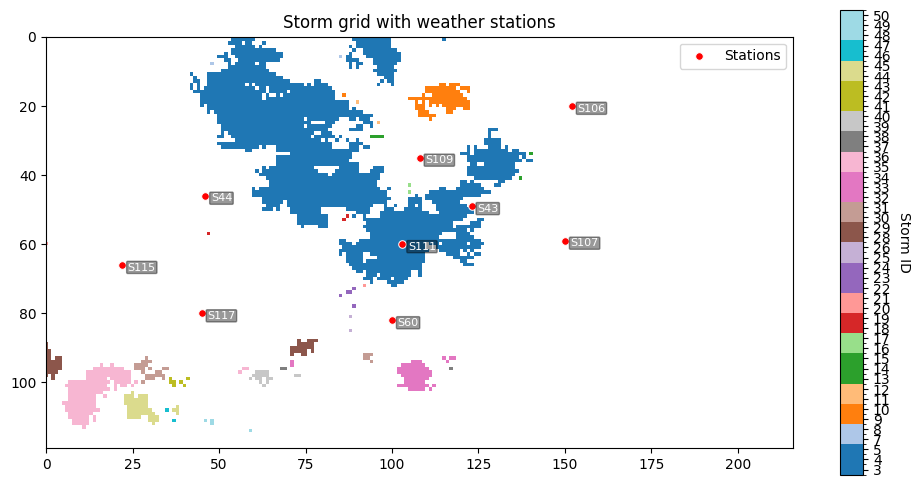

In [34]:
H, W = final_storm_grid.shape

# 1) Collect actual storm IDs (exclude background 0)
labels = np.array(sorted(np.unique(final_storm_grid)))
labels = labels[labels != 0]
N = len(labels)
if N == 0:
    labels = np.array([0]); N = 1

# 2) Map real labels -> 0..N-1 for coloring
lab2idx = {lab: i for i, lab in enumerate(labels)}
idx_grid = np.vectorize(lambda v: lab2idx.get(v, -1))(final_storm_grid)  # -1 for background

# 3) Build discrete colormap (one color per storm), mask background
cmap = plt.get_cmap("tab20", N)
norm = colors.BoundaryNorm(np.arange(N+1)-0.5, N)  # bins centered at 0..N-1
plot_data = np.ma.masked_where(idx_grid < 0, idx_grid)  # hide background

# 4) Plot
plt.figure(figsize=(10,5))
im = plt.imshow(plot_data, cmap=cmap, norm=norm, origin='upper')

# Colorbar with REAL storm IDs
cbar = plt.colorbar(im, ticks=np.arange(N))
cbar.ax.set_yticklabels([str(l) for l in labels])
cbar.set_label("Storm ID", rotation=270, labelpad=15)

# 5) Stations
xs = [xy[0] for xy in dummy_data["coord"]]
ys = [xy[1] for xy in dummy_data["coord"]]
plt.scatter(xs, ys, s=30, c='red', edgecolors='white', linewidths=0.7, label='Stations')

for sid, (x, y) in zip(dummy_data['station_id'], dummy_data['coord']):
    plt.annotate(str(sid), (x, y), xytext=(4, -4), textcoords='offset points',
                 fontsize=8, color='white', bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.4))

plt.xlim(0, W-1); plt.ylim(H-1, 0)
plt.title("Storm grid with weather stations")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()